# c) Avatar (movie) network (undirected, weighted)

- Nodes are characters. 
- Links represent a same-scene appearance between two characters in the moviea
- the weight gives the number of same-scene appearance.


*Source: J. Kaminski et al., "Moviegalaxies - Social Networks in Movies." https://doi.org/10.7910/DVN/T4HBA3, Harvard Dataverse, V3 (2018)*


In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import networkx as nx

In [30]:
ROOT = Path.cwd().parent
DATA_DIR = ROOT/"data"

nodes_path = DATA_DIR/"nodes.csv"
edges_path = DATA_DIR/"edges.csv"

nodes = pd.read_csv(nodes_path)
edges = pd.read_csv(edges_path)


In [31]:
nodes.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Id        30 non-null     int64
 1   Label     30 non-null     str  
 2   movie_id  30 non-null     int64
dtypes: int64(2), str(1)
memory usage: 852.0 bytes


In [32]:
nodes.head()

,Id,Label,movie_id
0,519631,JAKE,88
1,520100,QUARITCH,88
2,520425,SELFRIDGE,88
3,520314,GRACE,88
4,520156,NORM,88


In [33]:
edges.info()

<class 'pandas.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Source    105 non-null    int64
 1   Target    105 non-null    int64
 2   Type      105 non-null    str  
 3   Id        105 non-null    int64
 4   Label     105 non-null    int64
 5   Weight    105 non-null    int64
 6   movie_id  105 non-null    int64
dtypes: int64(6), str(1)
memory usage: 5.9 KB


In [34]:
edges.head()

,Source,Target,Type,Id,Label,Weight,movie_id
0,519777,519783,Undirected,0,17872,1,88
1,519965,519631,Undirected,1,17876,1,88
2,519965,520084,Undirected,2,17877,1,88
3,519965,520010,Undirected,3,17875,1,88
4,522131,520314,Undirected,4,18043,1,88


# week 1

1) Pick a social network among the one proposed on luiss.learn

2) Implement it in Python.

3) Draw the graph

4) Compute the number of nodes,edges, average degree and the density. Comment.


## point 1 and 2 graph implementations:

### 1.1) graph building

In [35]:
G = nx.Graph() # builds an empty undirected graph

# Add nodes with label attribute
for _, row in nodes.iterrows():
    G.add_node(row['Id'], label=row['Label'])

# Add edges with weight attribute
for _, row in edges.iterrows():
    G.add_edge(row['Source'], row['Target'], weight=row['Weight'])

### 1.2) graph plotting

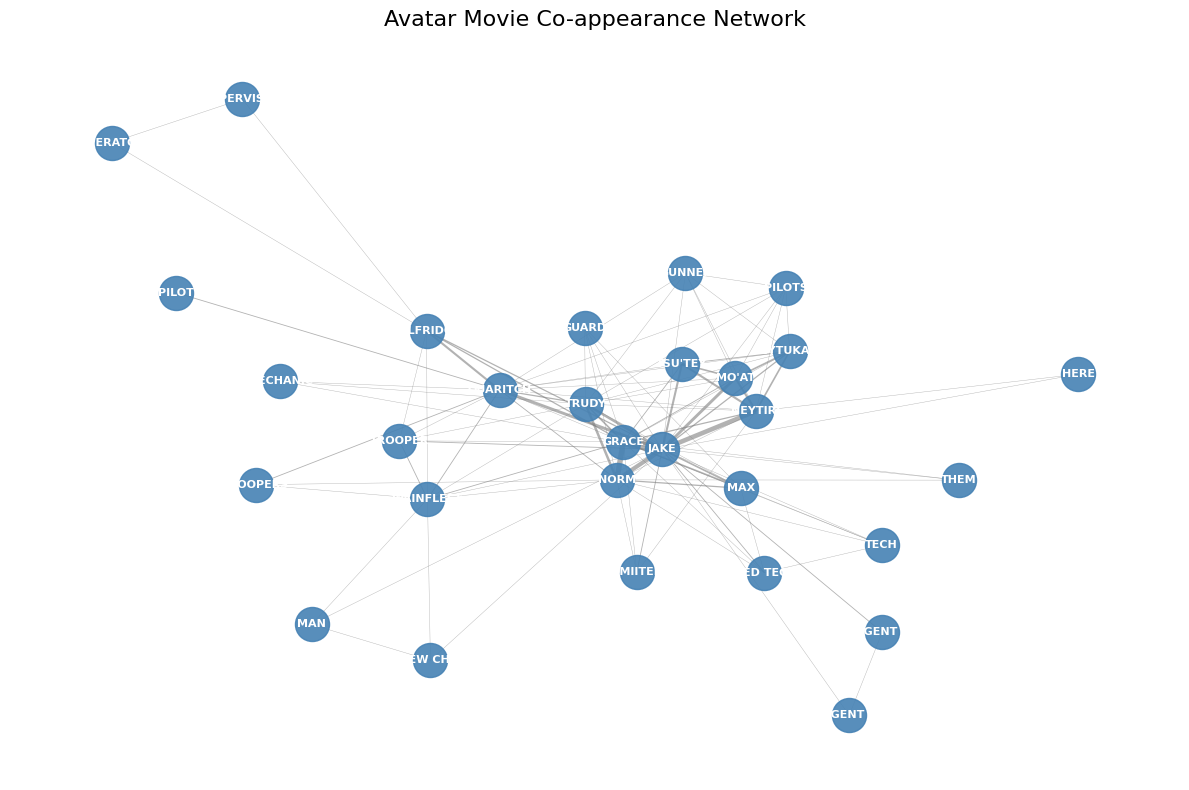

In [36]:
plt.figure(figsize=(12, 8))

pos = nx.spring_layout(G, seed=54)
labels = nx.get_node_attributes(G, 'label')
weights = [G[u][v]['weight'] for u, v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_size=600, node_color='steelblue', alpha=0.9)
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_color='white', font_weight='bold')
nx.draw_networkx_edges(G, pos, width=[w * 0.3 for w in weights], alpha=0.6, edge_color='gray')

plt.title("Avatar Movie Co-appearance Network", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()


### 1.3) Basic stats.

In [37]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
avg_degree = sum(dict(G.degree()).values()) / num_nodes
density = nx.density(G)

print(f"Number of nodes  : {num_nodes}")
print(f"Number of edges  : {num_edges}")
print(f"Average degree   : {avg_degree:.4f}")
print(f"Density          : {density:.4f}")


Number of nodes  : 30
Number of edges  : 105
Average degree   : 7.0000
Density          : 0.2414


"The Avatar co-appearance network has 30 nodes and 105 edges, with an average degree of 7.0, meaning each character shares scenes with 7 others on average. The density of 0.2414 indicates the network is moderately sparse — only ~24% of all possible connections exist — which makes sense as most characters only interact within specific subgroups (military vs. Na'vi)."

## Week 2

### 2.1) Clustering

In [ ]:
def clustering(G):
    clusters = dict()
    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        degree = len(neighbors)
        
        if degree <= 2: # if the degree is 2 we cannot have any cluster
            clusters[node] = 0.0
            continue
            
        triangles = sum(1 for i in range(degree) 
                          for j in range(i+1, degree) 
                          if G.has_edge(neighbors[i], neighbors[j]))
        local_wedges = degree * (degree - 1) / 2
        
        clusters[node] = triangles / local_wedges
        
    return clusters

In [49]:
def clustering(G): 
    clusters = dict()
    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        degree = len(neighbors)
        
        if degree < 2: #need at least 2 neighbors to form a triangle 
            clusters[node] = 0.0
            continue
            
        triangles = sum(1 for i in range(degree) for j in range(i+1, degree) if G.has_edge(neighbors[i], neighbors[j])) 
        local_wages = degree * (degree - 1) / 2 
        
        clusters[node] = triangles / local_wages
        
    return clusters

In [39]:
def average_clustering(G):
    c = clustering(G)
    return sum(c.values()) / len(c)

In [48]:
# My clustering
my_clustering = clustering(G)
my_avg = average_clustering(G)

# NetworkX built-ins
nx_clustering = nx.clustering(G)
nx_avg = nx.average_clustering(G)
nx_transitivity = nx.transitivity(G)

print(f"Custom average clustering   : {my_avg:.6f}")
print(f"NetworkX average clustering : {nx_avg:.6f}")
print(f"NetworkX transitivity       : {nx_transitivity:.6f}")


Custom average clustering   : 0.804295
NetworkX average clustering : 0.804295
NetworkX transitivity       : 0.500928


"Average clustering (0.80) is high, meaning most characters tend to appear in tight groups where their neighbors also know each other. Transitivity (0.50) is lower because it is a global ratio weighted by node degree — high-degree hub nodes like JAKE and GRACE form fewer closed triangles proportionally, pulling the global value down."

## week 3

1) Compute the cumulative distribution of the clustering

2) Define for every node the average of clustering of its neighbors. Compute the cumulative distribution

3) Compare the two distributions.


### 1) Compute the cumulative distribution of the clustering

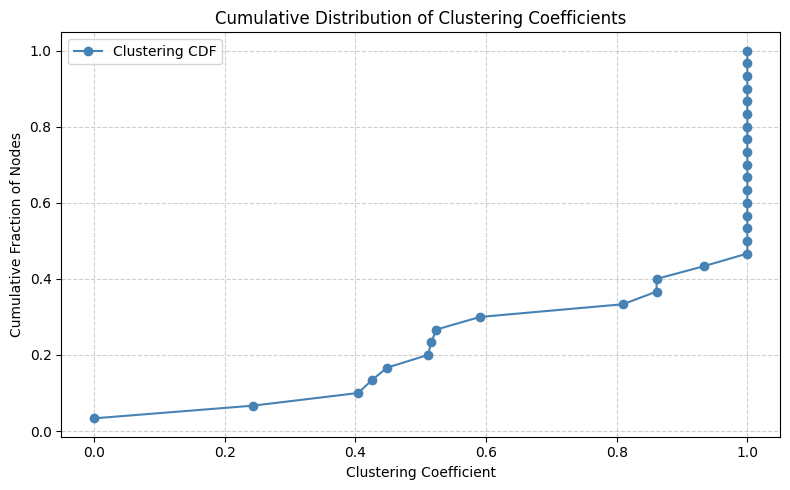

In [50]:
import numpy as np

# Get clustering values sorted
clust_values = sorted(my_clustering.values())
cdf = np.arange(1, len(clust_values) + 1) / len(clust_values)

plt.figure(figsize=(8, 5))
plt.plot(clust_values, cdf, marker='o', color='steelblue', label='Clustering CDF')
plt.xlabel('Clustering Coefficient')
plt.ylabel('Cumulative Fraction of Nodes')
plt.title('Cumulative Distribution of Clustering Coefficients')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


### 2) Define for every node the average of clustering of its neighbors. Compute the cumulative distribution

In [52]:
def avg_neighbor_clustering(G, clustering_dict):
    result = {}
    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        degree = len(neighbors)
        if degree == 0:
            result[node] = 0.0
        else:
            result[node] = np.mean([clustering_dict[n] for n in neighbors])
    return result

neighbor_avg_clust = avg_neighbor_clustering(G, my_clustering)


### 3) Compare the two distributions.

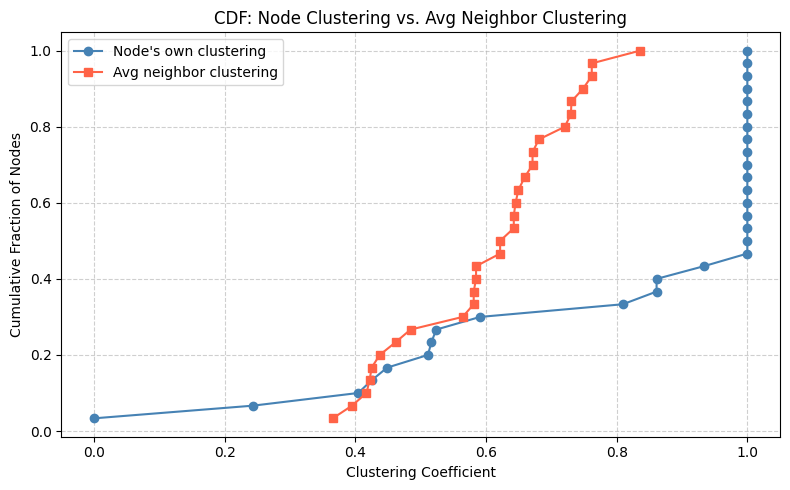

In [53]:
neigh_values = sorted(neighbor_avg_clust.values())
cdf_neigh = np.arange(1, len(neigh_values) + 1) / len(neigh_values)

plt.figure(figsize=(8, 5))
plt.plot(clust_values, cdf, marker='o', color='steelblue', label="Node's own clustering")
plt.plot(neigh_values, cdf_neigh, marker='s', color='tomato', label="Avg neighbor clustering")
plt.xlabel('Clustering Coefficient')
plt.ylabel('Cumulative Fraction of Nodes')
plt.title("CDF: Node Clustering vs. Avg Neighbor Clustering")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


Since clustering is a continuous value, we use the cumulative distribution function to represent it, avoiding arbitrary bin choices. The node clustering CDF shows that most characters have a high clustering coefficient (close to 1), reflecting the tight scene-groups of the movie. The neighbor clustering curve shifts left, meaning neighbors tend to have lower clustering than the nodes themselves — a sign of disassortative clustering structure.

## Week 5 

1) Depending on what seems more relevant in your graph, pick two of the following local notions

- Decay centrality
- Betweeness centrality
- Closeness centrality
- Any other notions that you invent
- Pagerank
2) Identify the most central nodes.


The most relevant for a co-appearance network are Betweenness and Closeness (Ele giustifica meglio questo punto)

In [59]:
largest_cc = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc).copy()
G_lcc.remove_edges_from(nx.selfloop_edges(G_lcc))

# Add inverse weight as distance attribute
for u, v, d in G_lcc.edges(data=True):
    d['inv_weight'] = 1 / d['weight']

betweenness = nx.betweenness_centrality(G_lcc, weight='inv_weight')
closeness   = nx.closeness_centrality(G_lcc, distance='inv_weight')


### identify most central nodes

In [60]:
df_centrality = pd.DataFrame({
    'Label'      : [G_lcc.nodes[n]['label'] for n in G_lcc.nodes()],
    'Betweenness': [betweenness[n] for n in G_lcc.nodes()],
    'Closeness'  : [closeness[n]   for n in G_lcc.nodes()]
})

df_centrality = df_centrality.sort_values('Betweenness', ascending=False).reset_index(drop=True)
print(df_centrality.to_string(index=False))


     Label  Betweenness  Closeness
      JAKE     0.736658   1.584044
  QUARITCH     0.172824   1.429379
 SELFRIDGE     0.133005   1.168066
     GRACE     0.067529   1.515022
   NEYTIRI     0.011084   1.429883
     TRUDY     0.005337   1.305861
      NORM     0.004721   1.416439
 WAINFLEET     0.002463   0.954434
       MAX     0.000616   1.174600
   EYTUKAN     0.000000   1.098188
     MO'AT     0.000000   1.338314
   TROOPER     0.000000   0.913099
   AGENT 1     0.000000   0.911732
   AGENT 2     0.000000   0.633083
CREW CHIEF     0.000000   0.647901
     GUARD     0.000000   0.634633
    GUNNER     0.000000   0.663652
      HERE     0.000000   0.628613
       MAN     0.000000   0.647901
  MECHANIC     0.000000   0.640676
  MED TECH     0.000000   0.911732
   OMIITED     0.000000   0.897622
  OPERATOR     0.000000   0.559550
     PILOT     0.000000   0.845764
    PILOTS     0.000000   0.663652
SUPERVISOR     0.000000   0.559550
      TECH     0.000000   0.639297
      THEM     0.000

###  visualize the centrality of the graph

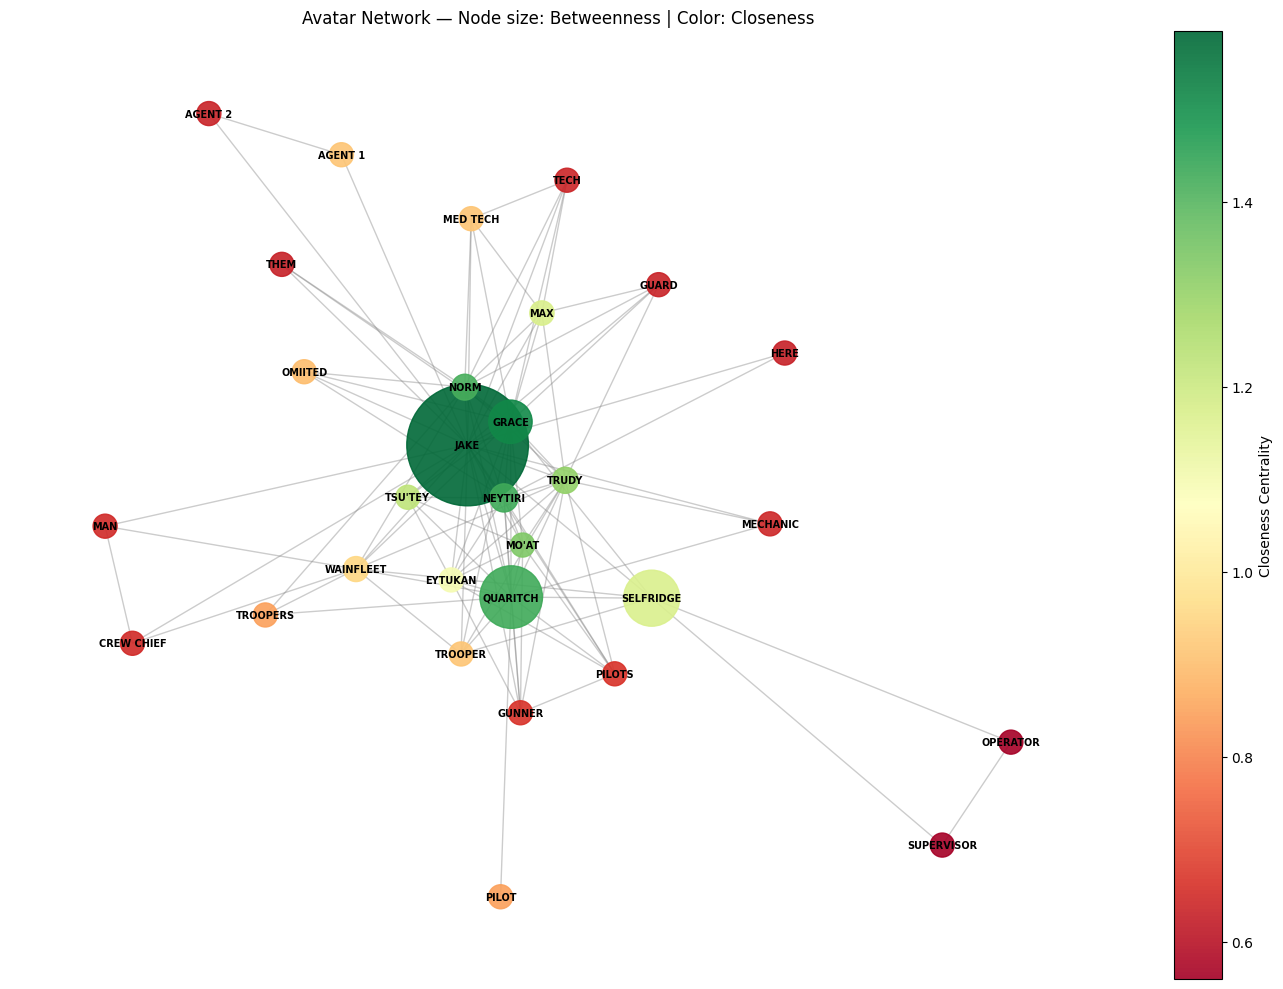

In [61]:
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G_lcc, seed=42)
labels = nx.get_node_attributes(G_lcc, 'label')

node_size  = [betweenness[n] * 10000 + 300 for n in G_lcc.nodes()]
node_color = [closeness[n] for n in G_lcc.nodes()]

nx.draw_networkx_edges(G_lcc, pos, alpha=0.4, edge_color='gray')
nc = nx.draw_networkx_nodes(G_lcc, pos, node_size=node_size, node_color=node_color, cmap=plt.cm.RdYlGn, alpha=0.9)
nx.draw_networkx_labels(G_lcc, pos, labels=labels, font_size=7, font_color='black', font_weight='bold')

plt.colorbar(nc, label='Closeness Centrality')
plt.title("Avatar Network — Node size: Betweenness | Color: Closeness")
plt.axis('off')
plt.tight_layout()
plt.show()


Betweenness centrality identifies characters who act as bridges between groups. JAKE dominates with a score of 0.42 — far above everyone else — confirming his role as the key connector between the human military and the Na'vi world. QUARITCH (0.14) and SELFRIDGE (0.13) follow, as they coordinate the human side of the story.
Closeness centrality measures how quickly a node can reach all others. Again JAKE ranks first (0.88), followed by GRACE (0.71) and QUARITCH (0.69), reflecting that these characters interact across multiple groups throughout the movie.
Peripheral characters like OPERATOR, SUPERVISOR, and PILOT score lowest on closeness (≈0.37–0.41), as they appear in very few scenes and are far from the core of the network.

## Week 6 

Treat your graph as undirected and unweighted. Delete loops and work on the resulting largest connected component.

: Implement two of the following three techniques for community detection:

a) Bridge removal (pick the partition with the highest modularity)

b) Modularity optimization

c) Label propagation.

In this case, you are allowed to use built-in functions from NetworkX.
Discuss which one you think is the best and why.

Provide a visualization for the partition you decided to be the best using Gephi ( https://gephi.org/gephi-lite/)

we'll go with b) Modularity optimization and c) Label propagation

In [62]:
# we build the unweighted copy
G_unw = nx.Graph()
G_unw.add_nodes_from(G_lcc.nodes(data=True))
G_unw.add_edges_from(G_lcc.edges())
G_unw.remove_edges_from(nx.selfloop_edges(G_unw))


In [63]:
from networkx.algorithms.community import greedy_modularity_communities

communities_mod = greedy_modularity_communities(G_unw)
modularity_mod  = nx.community.modularity(G_unw, communities_mod)

print(f"Modularity optimization — communities: {len(communities_mod)}, modularity: {modularity_mod:.4f}")


Modularity optimization — communities: 3, modularity: 0.2675


In [65]:
from networkx.algorithms.community import label_propagation_communities

communities_lp = label_propagation_communities(G_unw)
communities_lp = list(communities_lp)
modularity_lp  = nx.community.modularity(G_unw, communities_lp)

print(f"Label propagation — communities: {len(communities_lp)}, modularity: {modularity_lp:.4f}")


Label propagation — communities: 2, modularity: 0.0183


In [66]:
print("\n Modularity Optimization")
for i, comm in enumerate(communities_mod):
    names = [G_unw.nodes[n]['label'] for n in comm]
    print(f"Community {i+1}: {names}")

print("\n Label Propagation")
for i, comm in enumerate(communities_lp):
    names = [G_unw.nodes[n]['label'] for n in comm]
    print(f"Community {i+1}: {names}")



 Modularity Optimization
Community 1: ['GUNNER', "MO'AT", 'QUARITCH', 'PILOT', 'HERE', 'PILOTS', 'NEYTIRI', "TSU'TEY", 'EYTUKAN', 'TRUDY', 'MECHANIC']
Community 2: ['AGENT 1', 'OPERATOR', 'AGENT 2', 'SELFRIDGE', 'WAINFLEET', 'SUPERVISOR', 'JAKE', 'MAN', 'TROOPER', 'CREW CHIEF']
Community 3: ['MAX', 'GRACE', 'TROOPERS', 'OMIITED', 'TECH', 'MED TECH', 'THEM', 'NORM', 'GUARD']

 Label Propagation
Community 1: ['MAX', 'PILOT', 'PILOTS', 'TECH', 'EYTUKAN', 'MAN', 'TROOPER', 'TRUDY', 'CREW CHIEF', 'QUARITCH', 'MED TECH', 'GUARD', 'GUNNER', "MO'AT", 'WAINFLEET', 'TROOPERS', 'JAKE', "TSU'TEY", 'NORM', 'OMIITED', 'MECHANIC', 'AGENT 1', 'THEM', 'AGENT 2', 'SELFRIDGE', 'HERE', 'GRACE', 'NEYTIRI']
Community 2: ['OPERATOR', 'SUPERVISOR']


In [68]:
# Assign community ID to each node (use the best partition)
best_communities = communities_mod  # change if LP is better

for i, comm in enumerate(best_communities):
    for node in comm:
        G_unw.nodes[node]['community'] = i

# Export as GEXF for Gephi
nx.write_gexf(G_unw, "avatar_communities.gexf")


Modularity optimization finds 3 communities with a modularity of 0.2675, which, while moderate, reflects a meaningful partition: a Na'vi-centered group (Community 1), a human military group (Community 2), and a science/support group around Grace and Norm (Community 3). This aligns well with the actual plot structure of the movie.
Label propagation collapses almost the entire network into one single community (28 nodes), leaving only OPERATOR and SUPERVISOR isolated, with a near-zero modularity of 0.0183. This is a typical failure case of label propagation on dense, well-connected graphs — the algorithm spreads a single label across the whole network.
Modularity optimization is clearly the better choice, as it produces a meaningful and interpretable partition with a significantly higher modularity score.

# internal annotations for week 6: (must be removed before submission)
One remaining task — the assignment asks for an actual Gephi visualization screenshot. You still need to:
​

Open avatar_communities.gexf in gephi.org/gephi-lite

Color nodes by community attribute

Apply ForceAtlas2 layout

Take a screenshot for your submission